# Birds Metadata And CLIP Analysis

Notebook liczy tylko analizę gotowych danych: JS dla oczekiwanych relacji A->B, pełne directed JS do appendixa, rozkłady metadata oraz analogiczną analizę CLIP, jeśli plik CLIP istnieje.

In [1]:
from pathlib import Path
import sys

import pandas as pd


def _find_repo_root(start: Path = Path.cwd()) -> Path:
    candidates = [start, *start.parents, start / "cgsid"]
    for candidate in candidates:
        if (candidate / "src" / "cgsid").exists():
            return candidate
    raise FileNotFoundError("Could not find the cgsid repository root")


ROOT = _find_repo_root()
sys.path.insert(0, str(ROOT / "src"))

from cgsid.analysis.tools import (
    RelationSpec,
    all_directed_js,
    build_clip_metadata_from_mappings,
    clip_accuracy_by_label,
    expected_relation_table,
    format_clip_accuracy_table,
    plot_value_distributions,
    print_relation_tabs,
    value_distribution_table,
)
from cgsid.core.config import Settings

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 80)


In [2]:
DATASET = "birds"
DATASET_DIR = Settings().dataset_dir(DATASET)
METADATA_PATH = DATASET_DIR / "metadata.csv"
CLIP_PATH = DATASET_DIR / "clip_scores.csv"
COLUMNS = ["object_1_color", "pose", "day_time", "interaction"]
EXPECTED_RELATIONS: list[RelationSpec] = [
    ("pose -> color", "pose", "object_1_color"),
    ("pose -> time", "pose", "day_time"),
]


## Metadata

In [3]:
metadata_path = METADATA_PATH
if not metadata_path.exists():
    raise FileNotFoundError(f'Metadata file not found: {metadata_path}')
metadata = pd.read_csv(metadata_path).copy()
print(f'metadata: {metadata_path} rows={len(metadata)}')
metadata[COLUMNS].head()


metadata: /mnt/evafs/groups/mi2lab/ljaremek/cgsid_tmp/birds_correlated/metadata.csv rows=300


,object_1_color,pose,day_time,interaction
0,blue,flying,day,none
1,blue,flying,day,none
2,blue,flying,day,none
3,blue,flying,day,none
4,blue,flying,day,none


## Metadata Distributions

,dataset,column,column_label,value,value_label,count,proportion
0,metadata,object_1_color,Color,blue,blue,146,0.486667
1,metadata,object_1_color,Color,red,red,154,0.513333
2,metadata,pose,Pose,standing_on_branch,standing on branch,54,0.180000
3,metadata,pose,Pose,sitting_in_nest,sitting in nest,120,0.400000
4,metadata,pose,Pose,flying,flying,126,0.420000
5,metadata,day_time,Time of day,evening,evening,116,0.386667
6,metadata,day_time,Time of day,day,day,184,0.613333
7,metadata,interaction,Interaction,none,none,150,0.500000
8,metadata,interaction,Interaction,holding_worm_in_beak,worm in beak,150,0.500000


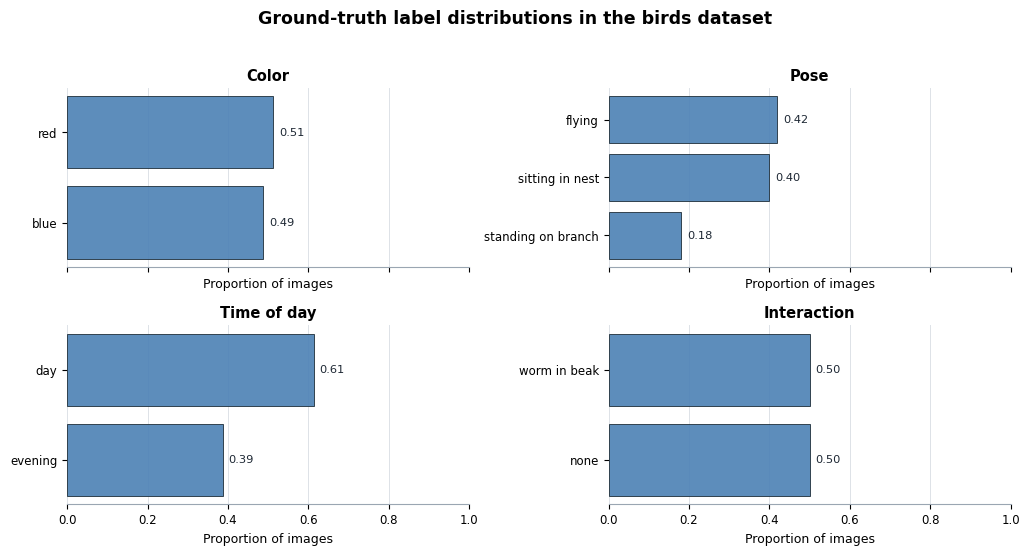

In [4]:
metadata_value_distributions = value_distribution_table(metadata[COLUMNS], "metadata")
display(metadata_value_distributions)

plot_value_distributions(
    metadata[COLUMNS],
    f"Ground-truth label distributions in the {DATASET} dataset",
    color="#4f83b6",
)


## Metadata Expected JS

In [5]:
metadata_expected_js = expected_relation_table(metadata, EXPECTED_RELATIONS)
display(metadata_expected_js)
print_relation_tabs(metadata, EXPECTED_RELATIONS)

,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value,reverse_weighted_js
0,pose -> time,pose,day_time,0.099817,0.132446,sitting_in_nest,0.099817
1,pose -> color,pose,object_1_color,0.066441,0.086730,sitting_in_nest,0.066441



=== pose -> color: pose -> object_1_color ===


object_1_color,blue,red
pose,,
flying,0.794,0.206
sitting_in_nest,0.167,0.833
standing_on_branch,0.481,0.519



=== pose -> time: pose -> day_time ===


day_time,day,evening
pose,,
flying,0.905,0.095
sitting_in_nest,0.200,0.800
standing_on_branch,0.852,0.148


## Metadata Full JS For Appendix

In [6]:
metadata_full_js = all_directed_js(metadata, COLUMNS)
display(metadata_full_js)


,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value
0,day_time -> pose,day_time,pose,0.099817,0.147391,evening
1,pose -> day_time,pose,day_time,0.099817,0.132446,sitting_in_nest
2,object_1_color -> pose,object_1_color,pose,0.066441,0.071666,blue
3,pose -> object_1_color,pose,object_1_color,0.066441,0.086730,sitting_in_nest
4,object_1_color -> day_time,object_1_color,day_time,0.017738,0.020106,blue
5,day_time -> object_1_color,day_time,object_1_color,0.017738,0.028634,evening
6,object_1_color -> interaction,object_1_color,interaction,0.000000,0.000000,blue
7,pose -> interaction,pose,interaction,0.000000,0.000000,flying
8,day_time -> interaction,day_time,interaction,0.000000,0.000000,day
9,interaction -> object_1_color,interaction,object_1_color,0.000000,0.000000,holding_worm_in_beak


## CLIP

In [7]:
CLIP_MAPPINGS: dict[str, dict[str, str]] = {
    "object_1_color": {
        "blue": "contains_color_blue",
        "red": "contains_color_red",
        "yellow": "contains_color_yellow",
        "green": "contains_color_green",
        "black": "contains_color_black",
        "white": "contains_color_white",
    },
    "pose": {
        "flying": "pose_flying",
        "sitting_in_nest": "pose_sitting_in_nest",
        "standing_on_branch": "pose_standing_on_branch",
    },
    "day_time": {
        "day": "time_day",
        "evening": "time_evening",
    },
    "interaction": {
        "holding_worm_in_beak": "interaction_holding_worm_in_beak",
        "none": "interaction_empty_beak",
    },
}


def build_clip_metadata(clip: pd.DataFrame) -> pd.DataFrame:
    return build_clip_metadata_from_mappings(clip, CLIP_MAPPINGS)


In [8]:
clip_path = CLIP_PATH
if not clip_path.exists():
    clip = None
    print(f'clip: no file found at {clip_path}')
    print('No CLIP results found yet. Run 2_query_dataset_with_clip_birds.py, then rerun from this cell.')
else:
    clip = pd.read_csv(clip_path)
    print(f'clip: {clip_path} rows={len(clip)}')
    clip_pred = build_clip_metadata(clip)
    display(clip_pred[COLUMNS].head())


clip: /mnt/evafs/groups/mi2lab/ljaremek/cgsid_tmp/birds_correlated/clip_scores.csv rows=300


,object_1_color,pose,day_time,interaction
0,blue,flying,day,none
1,blue,flying,day,holding_worm_in_beak
2,blue,flying,day,none
3,blue,flying,evening,holding_worm_in_beak
4,blue,flying,day,holding_worm_in_beak


## CLIP Distributions

,dataset,column,column_label,value,value_label,count,proportion
0,clip,object_1_color,Color,blue,blue,146,0.486667
1,clip,object_1_color,Color,red,red,154,0.513333
2,clip,pose,Pose,standing_on_branch,standing on branch,86,0.286667
3,clip,pose,Pose,sitting_in_nest,sitting in nest,88,0.293333
4,clip,pose,Pose,flying,flying,126,0.420000
5,clip,day_time,Time of day,evening,evening,136,0.453333
6,clip,day_time,Time of day,day,day,164,0.546667
7,clip,interaction,Interaction,holding_worm_in_beak,worm in beak,106,0.353333
8,clip,interaction,Interaction,none,none,194,0.646667


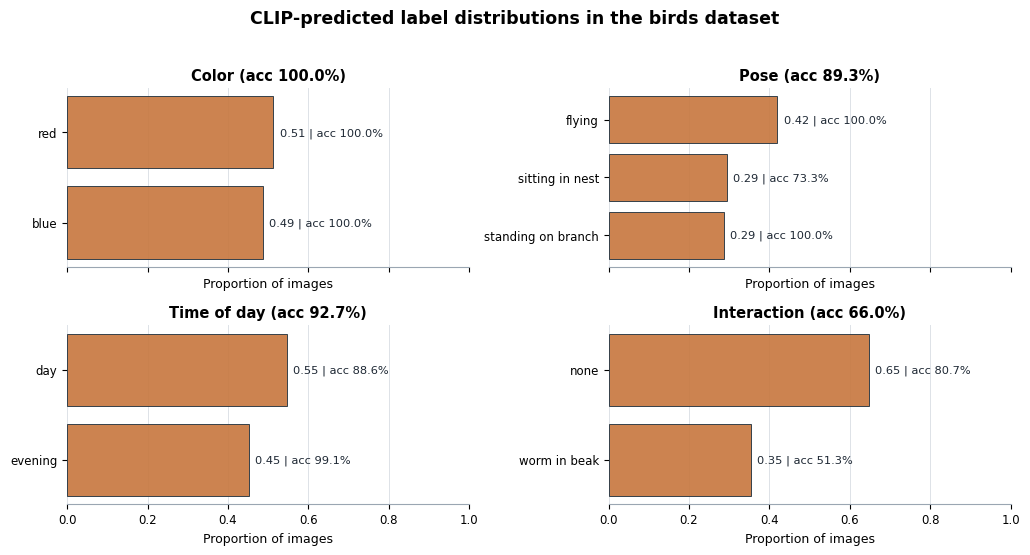

In [9]:
if clip is not None:
    clip_value_distributions = value_distribution_table(clip_pred[COLUMNS], "clip")
    display(clip_value_distributions)
    clip_accuracy_suffixes = {
        column: f"acc {100 * metadata[column].reset_index(drop=True).eq(clip_pred[column].reset_index(drop=True)).mean():.1f}%"
        for column in COLUMNS
    }
    clip_label_accuracy_suffixes = {}
    for column in COLUMNS:
        truth = metadata[column].reset_index(drop=True)
        pred = clip_pred[column].reset_index(drop=True)
        correct = truth.eq(pred)
        for value in sorted(truth.dropna().unique(), key=str):
            mask = truth.eq(value)
            if mask.any():
                clip_label_accuracy_suffixes[(column, value)] = f"acc {100 * correct[mask].mean():.1f}%"

    plot_value_distributions(
        clip_pred[COLUMNS],
        f"CLIP-predicted label distributions in the {DATASET} dataset",
        color="#c87941",
        title_suffixes=clip_accuracy_suffixes,
        value_suffixes=clip_label_accuracy_suffixes,
    )


## CLIP Accuracy Table


Accuracy helpers are imported from cgsid.analysis.tools.

In [10]:
if clip is not None:
    clip_accuracy = clip_accuracy_by_label(metadata, clip_pred, COLUMNS)
    display(format_clip_accuracy_table(clip_accuracy, dataset=DATASET))



Category,Label,Correct,Total,Accuracy [%],Share of dataset [%]
Color,All labels,300,300,100.00,100.00
Color,blue,146,146,100.00,48.67
Color,red,154,154,100.00,51.33
Pose,All labels,268,300,89.33,100.00
Pose,flying,126,126,100.00,42.00
Pose,standing on branch,54,54,100.00,18.00
Pose,sitting in nest,88,120,73.33,40.00
Time of day,All labels,278,300,92.67,100.00
Time of day,evening,115,116,99.14,38.67
Time of day,day,163,184,88.59,61.33


## CLIP Expected JS

In [11]:
if clip is not None:
    clip_expected_js = expected_relation_table(clip_pred, EXPECTED_RELATIONS)
    display(clip_expected_js)
    print_relation_tabs(clip_pred, EXPECTED_RELATIONS)

,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value,reverse_weighted_js
0,pose -> color,pose,object_1_color,0.059866,0.084334,sitting_in_nest,0.059866
1,pose -> time,pose,day_time,0.045512,0.107276,sitting_in_nest,0.045512



=== pose -> color: pose -> object_1_color ===


object_1_color,blue,red
pose,,
flying,0.794,0.206
sitting_in_nest,0.170,0.830
standing_on_branch,0.360,0.640



=== pose -> time: pose -> day_time ===


day_time,day,evening
pose,,
flying,0.738,0.262
sitting_in_nest,0.182,0.818
standing_on_branch,0.640,0.360


## CLIP Full JS For Appendix

In [12]:
if clip is not None:
    clip_full_js = all_directed_js(clip_pred, COLUMNS)
    display(clip_full_js)


,relation,condition_column,target_column,weighted_js,max_js,strongest_condition_value
0,pose -> interaction,pose,interaction,0.069834,0.084820,sitting_in_nest
1,interaction -> pose,interaction,pose,0.069834,0.126049,holding_worm_in_beak
2,object_1_color -> interaction,object_1_color,interaction,0.066155,0.075768,red
3,interaction -> object_1_color,interaction,object_1_color,0.066155,0.126003,holding_worm_in_beak
4,object_1_color -> pose,object_1_color,pose,0.059866,0.061636,blue
5,pose -> object_1_color,pose,object_1_color,0.059866,0.084334,sitting_in_nest
6,pose -> day_time,pose,day_time,0.045512,0.107276,sitting_in_nest
7,day_time -> pose,day_time,pose,0.045512,0.046324,day
8,day_time -> interaction,day_time,interaction,0.014996,0.019642,evening
9,interaction -> day_time,interaction,day_time,0.014996,0.028308,holding_worm_in_beak


## Metadata vs CLIP Summary

In [13]:
if clip is not None:
    comparison = metadata_expected_js.merge(clip_expected_js, on=['relation', 'condition_column', 'target_column'], suffixes=('_metadata', '_clip'))
    comparison['weighted_js_delta_metadata_minus_clip'] = comparison['weighted_js_metadata'] - comparison['weighted_js_clip']
    display(comparison)

    wjs_comparison = metadata_full_js.merge(clip_full_js, on=['relation', 'condition_column', 'target_column'], suffixes=('_metadata', '_clip'))
    wjs_summary = wjs_comparison[['relation', 'weighted_js_metadata', 'weighted_js_clip']].rename(columns={
        'weighted_js_metadata': 'wjs (raw)',
        'weighted_js_clip': 'wjs (clip)',
    })
    wjs_summary = (
        wjs_summary
        .assign(_raw_sort=wjs_summary['wjs (raw)'].round(6), _clip_sort=wjs_summary['wjs (clip)'].round(6))
        .sort_values(['_raw_sort', '_clip_sort'], ascending=False)
        .drop(columns=['_raw_sort', '_clip_sort'])
        .reset_index(drop=True)
    )
    display(wjs_summary.style.format({'wjs (raw)': '{:.6f}', 'wjs (clip)': '{:.6f}'}))

,relation,condition_column,target_column,weighted_js_metadata,max_js_metadata,strongest_condition_value_metadata,reverse_weighted_js_metadata,weighted_js_clip,max_js_clip,strongest_condition_value_clip,reverse_weighted_js_clip,weighted_js_delta_metadata_minus_clip
0,pose -> time,pose,day_time,0.099817,0.132446,sitting_in_nest,0.099817,0.045512,0.107276,sitting_in_nest,0.045512,0.054305
1,pose -> color,pose,object_1_color,0.066441,0.086730,sitting_in_nest,0.066441,0.059866,0.084334,sitting_in_nest,0.059866,0.006575


,relation,wjs (raw),wjs (clip)
0,day_time -> pose,0.099817,0.045512
1,pose -> day_time,0.099817,0.045512
2,object_1_color -> pose,0.066441,0.059866
3,pose -> object_1_color,0.066441,0.059866
4,object_1_color -> day_time,0.017738,0.004850
5,day_time -> object_1_color,0.017738,0.004850
6,pose -> interaction,0.000000,0.069834
7,interaction -> pose,0.000000,0.069834
8,object_1_color -> interaction,0.000000,0.066155
9,interaction -> object_1_color,0.000000,0.066155
